<a href="https://colab.research.google.com/github/apy9955/CodeAlpha_Handwritten_Character_Recognition/blob/main/Handwritten_Character_Recognition_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

from sklearn.metrics import accuracy_score

In [3]:
!pip install tensorflow

In [4]:
import tensorflow as tf
print(tf.__version__)

2.20.0


In [6]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Training Shape: (60000, 28, 28)
Testing Shape: (10000, 28, 28)


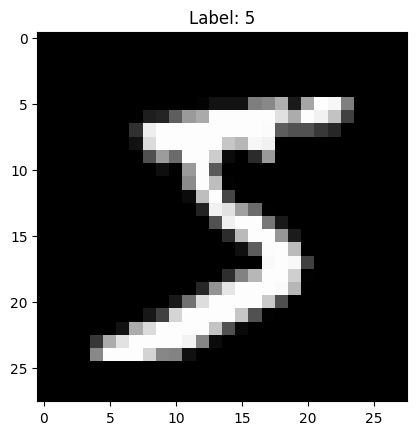

In [7]:
plt.imshow(X_train[0], cmap='gray')
plt.title(f"Label: {y_train[0]}")
plt.show()

In [8]:
X_train = X_train / 255.0
X_test = X_test / 255.0

In [9]:
X_train = X_train.reshape(60000, 28, 28, 1)
X_test = X_test.reshape(10000, 28, 28, 1)

print(X_train.shape)
print(X_test.shape)

(60000, 28, 28, 1)
(10000, 28, 28, 1)


In [10]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
history = model.fit(
    X_train,
    y_train,
    epochs=5,
    validation_data=(X_test, y_test)
)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 71s 37ms/step - accuracy: 0.9604 - loss: 0.1282 - val_accuracy: 0.9825 - val_loss: 0.0524
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 75s 33ms/step - accuracy: 0.9865 - loss: 0.0430 - val_accuracy: 0.9875 - val_loss: 0.0346
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 80s 32ms/step - accuracy: 0.9910 - loss: 0.0297 - val_accuracy: 0.9881 - val_loss: 0.0330
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 85s 33ms/step - accuracy: 0.9931 - loss: 0.0210 - val_accuracy: 0.9922 - val_loss: 0.0248
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 60s 32ms/step - accuracy: 0.9951 - loss: 0.0152 - val_accuracy: 0.9903 - val_loss: 0.0298


In [12]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9903 - loss: 0.0298
Test Accuracy: 0.9902999997138977


In [13]:
predictions = model.predict(X_test)

print("Predicted:", np.argmax(predictions[0]))
print("Actual:", y_test[0])

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step
Predicted: 7
Actual: 7


In [15]:
model.save("handwritten_character_model.h5")

In [16]:
report = pd.DataFrame({
    "Metric": ["Accuracy"],
    "Value": [accuracy]
})

report

,Metric,Value
0,Accuracy,0.9903


In [17]:
report.to_csv("Handwritten_Character_Report.csv", index=False)

In [18]:
import os
print(os.listdir())

['.config', 'Handwritten_Character_Report.csv', 'handwritten_character_model.h5', 'sample_data']


In [19]:
from google.colab import files

files.download("handwritten_character_model.h5")
files.download("Handwritten_Character_Report.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>